---
title: ODEs and the Euler method
sidebarTitle: ODEs and Euler
description: A first look at ordinary differential equations and their simplest numerical solver, the Euler method, with worked examples that bridge into flow matching.
tag: "DRAFT"
---

An **ordinary differential equation (ODE)** is a relation that tells you the rate of change of a quantity. Instead of writing down the quantity directly, you write down its derivative and an initial condition, and the ODE itself encodes everything else.

The simplest example is

$$
\frac{d y}{d t} = f(y, t), \qquad y(0) = y_0.
$$

At every instant $t$, the slope of $y$ is dictated by the function $f$ evaluated at the current state $(y, t)$. Solving the ODE means recovering the function $y(t)$ that satisfies this relation.

## A first example: exponential growth

Take the most famous ODE of all:

$$
\frac{d y}{d t} = y, \qquad y(0) = 1.
$$

In words: *the rate of change of $y$ equals $y$ itself*. Populations, compound interest, and unstable physical systems all obey this law in some regime.

You can write down the closed-form solution by inspection: the only function whose derivative equals itself is the exponential, so

$$
y(t) = e^t.
$$

That is the analytical solution. For most ODEs you encounter in practice there is no analytical solution, and you have to compute $y(t)$ numerically. The simplest numerical method is the **Euler method**.

## The Euler method

The idea is to take a tiny step in the direction the derivative tells you to go, then repeat.

Pick a small step size $\Delta t$. Starting from $(t_0, y_0) = (0, 1)$, replace the smooth ODE with a discrete update:

$$
y_{n+1} = y_n + \Delta t \cdot f(y_n, t_n), \qquad t_{n+1} = t_n + \Delta t.
$$

At each step you compute the slope at the current point and take a step of length $\Delta t$ in that direction. After $N$ steps you have an approximation of $y$ at time $t = N \Delta t$.

Two lines of Python implement it.

In [1]:
import numpy as np
import matplotlib.pyplot as plt


def euler(f, y0, t0, t_end, dt):
    """Euler method: integrate dy/dt = f(y, t) from t0 to t_end.

    Returns arrays (t_grid, y_trajectory).
    """
    n_steps = int(np.round((t_end - t0) / dt))
    t = np.empty(n_steps + 1)
    y = np.empty(n_steps + 1)
    t[0], y[0] = t0, y0
    for n in range(n_steps):
        y[n + 1] = y[n] + dt * f(y[n], t[n])
        t[n + 1] = t[n] + dt
    return t, y


# Exponential growth: dy/dt = y
f_exp = lambda y, t: y

t_euler, y_euler = euler(f_exp, y0=1.0, t0=0.0, t_end=2.0, dt=0.2)
t_dense = np.linspace(0, 2, 200)
y_exact = np.exp(t_dense)

print(f"Euler at t=2.0 (dt=0.2):  {y_euler[-1]:.4f}")
print(f"Exact at t=2.0:           {np.exp(2.0):.4f}")
print(f"Relative error:           {abs(y_euler[-1] - np.exp(2.0)) / np.exp(2.0):.2%}")

Euler at t=2.0 (dt=0.2):  6.1917
Exact at t=2.0:           7.3891
Relative error:           16.20%


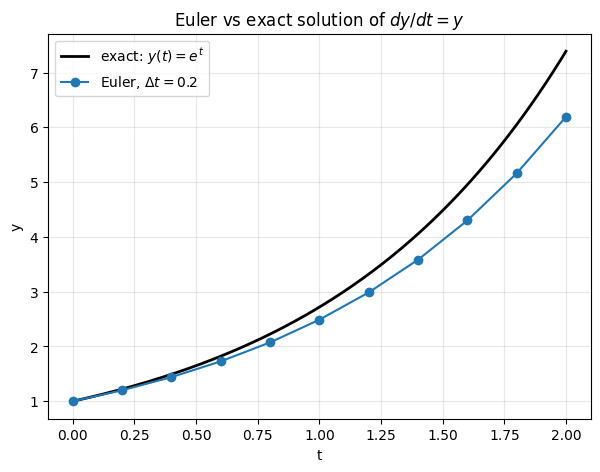

In [2]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(t_dense, y_exact, "k-", lw=2, label="exact: $y(t)=e^t$")
ax.plot(t_euler, y_euler, "o-", color="C0", label="Euler, $\\Delta t=0.2$")
ax.set_xlabel("t"); ax.set_ylabel("y")
ax.set_title("Euler vs exact solution of $dy/dt = y$")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

Euler under-shoots the exact curve. That is no accident: with $\Delta t = 0.2$ each step uses the slope at the *start* of the interval, but the true slope grows over the interval, so the discrete update consistently lags behind. Two natural questions follow:

1. What happens if you shrink $\Delta t$?
2. How fast does the error shrink as $\Delta t \to 0$?

## Step size and error

The Euler method is **first-order accurate**: the global error at a fixed final time scales linearly with $\Delta t$. Halving $\Delta t$ roughly halves the error.

You can verify this by running Euler at several step sizes and plotting the error at $t = 2$ on a log-log axis. A first-order method gives a straight line of slope 1.

In [3]:
dts = np.array([0.5, 0.2, 0.1, 0.05, 0.02, 0.01, 0.005])
errors = []
for dt in dts:
    _, y = euler(f_exp, y0=1.0, t0=0.0, t_end=2.0, dt=dt)
    errors.append(abs(y[-1] - np.exp(2.0)))
errors = np.array(errors)

for dt, err in zip(dts, errors):
    print(f"dt={dt:6.3f}   |error| at t=2.0 = {err:.4e}")

dt= 0.500   |error| at t=2.0 = 2.3266e+00
dt= 0.200   |error| at t=2.0 = 1.1973e+00
dt= 0.100   |error| at t=2.0 = 6.6156e-01
dt= 0.050   |error| at t=2.0 = 3.4907e-01
dt= 0.020   |error| at t=2.0 = 1.4441e-01
dt= 0.010   |error| at t=2.0 = 7.3038e-02
dt= 0.005   |error| at t=2.0 = 3.6731e-02


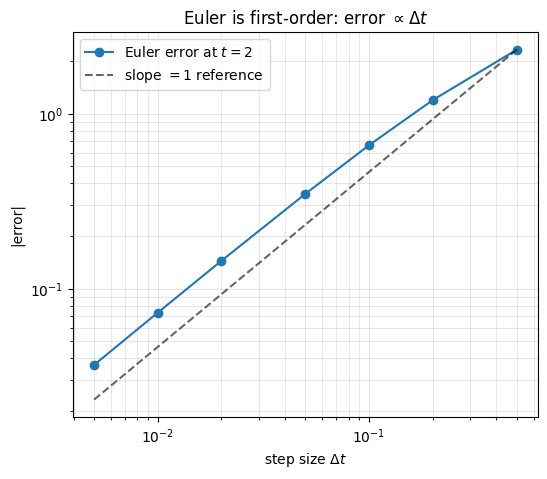

In [4]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.loglog(dts, errors, "o-", color="C0", label="Euler error at $t=2$")
ax.loglog(dts, errors[0] * (dts / dts[0]), "k--", alpha=0.6, label="slope $=1$ reference")
ax.set_xlabel("step size $\\Delta t$"); ax.set_ylabel("|error|")
ax.set_title("Euler is first-order: error $\\propto \\Delta t$")
ax.legend()
ax.grid(alpha=0.3, which="both")
plt.show()

The data points lie on the reference line of slope $1$, which is what *first-order accurate* means. Higher-order methods like Heun (slope $2$) or RK4 (slope $4$) buy more accuracy per step, but they all follow the same recipe: take a step in the direction the derivative tells you to go.

For everything that follows in this book, the Euler step is enough to build intuition. You only need to know that better integrators exist and that they integrate the *same* ODE.

## A 2D example: rotation

ODEs are not restricted to scalar $y$. The state can be a vector $\mathbf{x} \in \mathbb{R}^d$, and the right-hand side becomes a vector-valued function $\mathbf{v}(\mathbf{x}, t) \in \mathbb{R}^d$:

$$
\frac{d \mathbf{x}}{d t} = \mathbf{v}(\mathbf{x}, t), \qquad \mathbf{x}(0) = \mathbf{x}_0.
$$

The vector field $\mathbf{v}$ assigns a velocity to every point in space, and the ODE says *follow that velocity*. The Euler update is identical, just vectorized:

$$
\mathbf{x}_{n+1} = \mathbf{x}_n + \Delta t \cdot \mathbf{v}(\mathbf{x}_n, t_n).
$$

A clean 2D example is **pure rotation**:

$$
\mathbf{v}(x, y) = \begin{bmatrix} -y \\ x \end{bmatrix}.
$$

Each particle at position $(x, y)$ gets a velocity perpendicular to its position vector. The exact trajectories are circles around the origin, traced counterclockwise.

In [5]:
def euler_vec(v, x0, t0, t_end, dt):
    """Euler method for vector ODE dx/dt = v(x, t). x is a 1-D array."""
    n_steps = int(np.round((t_end - t0) / dt))
    xs = np.empty((n_steps + 1, len(x0)))
    xs[0] = x0
    t = t0
    for n in range(n_steps):
        xs[n + 1] = xs[n] + dt * v(xs[n], t)
        t += dt
    return xs


# Pure rotation
v_rot = lambda x, t: np.array([-x[1], x[0]])

# Release a few particles, integrate one full revolution (2*pi)
starts = [(1.0, 0.0), (2.0, 0.0), (0.0, 1.5), (-1.0, -1.0)]
trajectories = [euler_vec(v_rot, np.array(s), t0=0.0, t_end=2 * np.pi, dt=0.02)
                for s in starts]

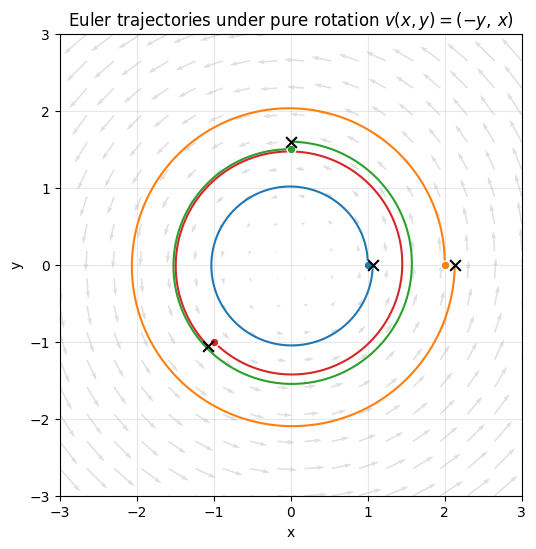

In [6]:
fig, ax = plt.subplots(figsize=(6, 6))

# Quiver of the field
xx, yy = np.meshgrid(np.linspace(-3, 3, 18), np.linspace(-3, 3, 18))
ax.quiver(xx, yy, -yy, xx, color="lightgray", alpha=0.7, scale=60)

# Euler trajectories
for s, traj in zip(starts, trajectories):
    ax.plot(traj[:, 0], traj[:, 1], lw=1.5)
    ax.scatter(*s, s=40, zorder=3, edgecolor="white", linewidth=1.0)
    ax.scatter(traj[-1, 0], traj[-1, 1], marker="x", s=60, color="black", zorder=3)

ax.set_aspect("equal")
ax.set_xlim(-3, 3); ax.set_ylim(-3, 3)
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_title("Euler trajectories under pure rotation $v(x,y)=(-y,\\,x)$")
ax.grid(alpha=0.3)
plt.show()

The black ✕ marks show where each particle ends up after $t = 2\pi$. With Euler the endpoints drift slightly outward, the same first-order error you saw in 1D. Shrinking $\Delta t$ pulls the endpoints back toward their starting circles. Switching to a higher-order solver eliminates the drift faster than refining $\Delta t$ does.

## Where this leads

That last figure is the whole picture of how modern generative models sample. Replace the hand-written rotation field with a **learned** vector field $\mathbf{v}_\theta(\mathbf{x}, t)$, parameterized by a neural network. Start the particles from Gaussian noise instead of arbitrary points. Run the same Euler loop you just wrote.

- If $\mathbf{v}_\theta$ was trained to match a target velocity field connecting Gaussian noise to the data distribution, you have **[flow matching](/aiml-common/lectures/flow-matching/index)**.
- If $\mathbf{v}_\theta$ encodes the score of a noise-perturbed data distribution, you have a **diffusion model** in its probability-flow ODE form.

Both are this notebook with a bigger vector field. Everything else, picking $\mathbf{v}_\theta$, choosing the probability path, regressing the network on a clever target, is decoration on top of the same Euler step.

## References

- L. C. Evans, *Partial Differential Equations* (Chapter 1), for ODE basics and existence/uniqueness.
- E. Hairer, S. P. Nørsett, G. Wanner, *Solving Ordinary Differential Equations I*, the standard reference on Euler and its successors.
- Khan Academy, [Differential equations](https://www.khanacademy.org/math/differential-equations), for a gentler video-first introduction.